In [ ]:
#Candidate number: 291076

1) To find the theoretical running time, I'll analyse the formula:
$$Cosine Similarity = cos(\theta) = \frac{A \cdot B} {\sqrt {A \cdot A \times B \cdot B}}$$

It consists of the dot product of two vectors ($A$ and $B$) as the numerator, and the multiplication of the dot product of $A$ with itself and $B$ with itself, all square rooted as the denominator.

$A \cdot B$ represents the operation $$\mathbf{A} \cdot \mathbf{B} = \sum_{i=1}^{n} A_i B_i$$ So a simple multiplication operation between $A_i B_i$ with time complexity $0(1)$, $A$ and $B$ are of equal lengths, $n$, and this multiplication happens between every ith element of $A$ and $B$, and so the time it takes is dependent on $n$, thus is of $O(n)$ time complexity. The summation of all of those results is addition ($O(1)$) carried out $n-1$ times, making this $\approx O(n)$ also. As $O(n)$ is the highest degree of time complexity here these dominate this expression, so the overall time complexity for the numerator in cosine similarity is $2O(n) \approx O(n)$ 

Similarly, the $A \cdot A$ component and $B \cdot B$ component are also $O(n)$ time complexity. The multiplication of $A \cdot A$ with  $B \cdot B$ is ($O(1)$), finding the root of this is $O(1)$, finally- dividing the numerator by the denominator is also $O(1)$, the $O(n)$ terms dominate the time complexity and so the overall theoretical time complexity for calculating cosine similarity on a pair of vectors is therefore $O(n)$.
To test this empirically I will time how long it takes for cosine similarity to compute between two documents, represented as word frequency vectors (WFV), sliced to different lengths. I would expect to see a linear increase in time taken to compute with the increase in length of the WFV. To confirm I will normalise the data to $log_{10}$ and make note of the slope. If it comes out to $\approx 1$ this will suggest that the time increase is indeed linear with increase in length of the WFV
.

In [1]:
import pandas as pd #imports for entire assignment
import time
import math
import numpy as np
from numpy import dot
import scipy.stats as stats
import matplotlib.pyplot as plt
import random
from numpy.linalg import norm
from multiprocessing import Pool
import time
import os
import myworker

data1=pd.read_csv('data2024.csv', index_col=0)

my_data_array=data1.values

documents1 = data1.to_numpy()

In [2]:
#doc_by_ref1 = data1.iloc[:,0]
#doc_by_ref2 = data1.iloc[:,1]
#print(doc_by_ref1)

doc_1 = my_data_array[:,0] #first column as a list
doc_2 = my_data_array[:,1] #second
doc_3 = my_data_array[:,2]

length_of_data = len(doc_1)

list_of_docs = [my_data_array[:,i] for i in range(15)]

array_of_docs = np.array(list_of_docs)

array1 = np.array(doc_1)
array2 = np.array(doc_2)
#print(list_of_docs)
def dotn(v1,v2):
    """Naive dot product of 2 vectors
args: vector 1 and vector 2
return: dot product as a float value
"""
    total=0
    for i in range(0,len(v1)): #for every item in the vector
        total+=v1[i]*v2[i] #multiply every ith element from vector 1 with the ith element from vector 2
        
    return total

def cosine_n(v1,v2): #cosine naive
    """Naive cosine similarity
args: vector 1 and vector 2
return: the cosine similarity of 2 vectors as a float value"""    
    return dotn(v1,v2)/math.sqrt(dotn(v1,v1)*dotn(v2,v2))

cos_of_pair12 = cosine_n(doc_1,doc_2)
print(cos_of_pair12) #gives 0.94097


0.940967450115047


In [3]:
def timeit(somefunc,*args,repeats=200,**kwargs):
    """Function for timing other functions
args: a function, positional arguments associated with the function, nuumber of repeats, key word arguments
return: the mean time taken for the function to complete"""
    times=[]
  
    while repeats>0:
        starttime=time.time()
        ans=somefunc(*args,**kwargs)
        endtime=time.time()
        timetaken=endtime-starttime
        times.append(timetaken)
        repeats-=1
    
    mean=np.mean(times)
    stdev=np.std(times)
 
    return (mean)

x_cos =[]
y_cos =[]

In [4]:
def make_data(start, end, jump, some_func, v1, v2, repeats=20, *args, **kwargs):
    """
    Generate datasets by applying the `timeit` function on `some_func` over a range of inputs.

    args:
        start (int)
        end (int)
        jump (int)
        some_func (function): Function to be timed, which takes two positional arguments.
        v1 (list or np.ndarray): The first argument to `some_func` (list or vector to be sliced).
        v2 (list or np.ndarray): The second argument to `some_func` (list or vector to be sliced).
        repeats (int): Number of times to repeat the timing .
        *args: Additional positional arguments for `some_func`.
        **kwargs: Additional keyword arguments for `some_func`.

    returns:
        tuple: (x_data, y_data) where x_data is the range of `n` and y_data is the mean times.
    """
    x_data = []
    y_data = []

    for n in range(start, end, jump):
        # Dynamically slice v1 and v2 based on n
        sliced_v1 = v1[:n]
        sliced_v2 = v2[:n]
        
        # Time the function with the dynamically sliced arguments
        mean_time = timeit(some_func, sliced_v1, sliced_v2, repeats=repeats, *args, **kwargs)
        
        # Store the results
        x_data.append(n)
        y_data.append(mean_time)

    return x_data, y_data


In [5]:
(x_cos, y_cos) = make_data(50, length_of_data, 200, cosine_n, array1,array2,repeats= 100) # start must be at least 38 as doc 2 is zeros until then
(x_adjust, y_adjust) = make_data(5000, length_of_data, 200, cosine_n, array1,array2,repeats= 100) # for use in later graph

In [56]:
# Non scaled data:
# plt.scatter(x_cos,y_cos)
# plt.xlabel("Length of vector")
# plt.ylabel("Average time taken in seconds")
# plt.title("Time to calculate Cosine Similarity between 2 documents represented as vectors of word frequencies of varied lengths")
# plt.show()

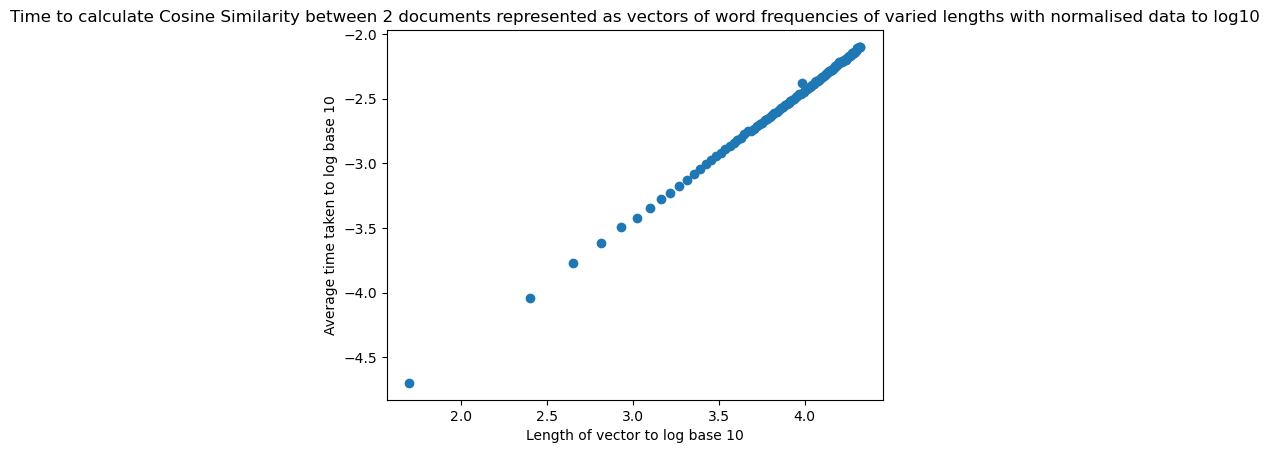

Slope is 1.0009814359961748 and intercept is -6.435332327156982


In [31]:
log_xcos=[np.log10(x) for x in x_cos]
log_ycos=[np.log10(y) for y in y_cos]
log_x_adjust =[np.log10(x) for x in x_adjust] #for later graph
log_y_adjust =[np.log10(y) for y in y_adjust] # for later graph
plt.scatter(log_xcos,log_ycos)
plt.xlabel("Length of vector to log base 10")
plt.ylabel("Average time taken in seconds to log base 10")
plt.title("Time to calculate Cosine Similarity between 2 documents represented as vectors of word frequencies of varied lengths with normalised data to log10")
plt.show()

res = stats.linregress(log_xcos, log_ycos)
print("Slope is {} and intercept is {}".format(res.slope,res.intercept))

With a time complexity of $0(n)$ one would expect the slope of the data sets (to log10) to be near 1, consistent with the observed result 1.0010 (to 5 s.f.). Calculating the y intercept from the logged data: $10^-6.40994 \approx 3.89\times10^{-7}$. With retests the slope varies from $0.94-1.03$. I would put the fact that it dips below the theoretical limit down to inbuilt time-saves within my computer and/or python, and the intercept varies between $3\times10^{-7}$ and $7\times10^{-7}$. The y-intercept, representing the overhead time for the calculation, is minuscule. Its variability likely arises from CPU multitasking, but as it is nearly instantaneous, even small additional tasks can cause noticeable fluctuations.

In [6]:
array1 = np.array(doc_1)
array2 = np.array(doc_2)

def numpy_cosine(v1,v2):
     return np.dot(v1,v2)/(np.sqrt(norm(v1)*norm(v2)))
#Numpy calculates so fast that it causes multiple divide by zero errors when converting to logarithmic scales
#so a much longer starting length is required:
(x_cos_numpy, y_cos_numpy) = make_data(5000, length_of_data, 100, numpy_cosine, array1, array2, repeats=2000) 

In [55]:
# Non-scaled data:
# plt.scatter(x_cos_numpy, y_cos_numpy)
# plt.xlabel("Length of vector")
# plt.ylabel("Average time taken in seconds")
# plt.title("Time to calculate Cosine Similarity using numpy dot between 2 documents represented as vectors of word frequencies of varied lengths")
# plt.show()


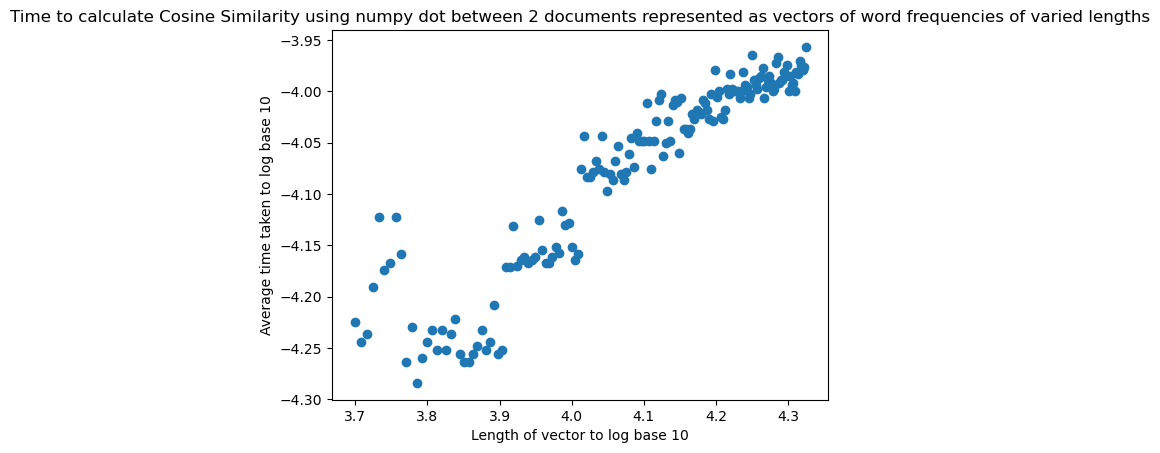

In [36]:
log_xcos_numpy = [np.log10(x) for x in x_cos_numpy]
log_ycos_numpy = [np.log10(y) for y in y_cos_numpy]
#print(log_ycos_numpy)
plt.scatter(log_xcos_numpy,log_ycos_numpy)
plt.xlabel("Length of vector to log base 10")
plt.ylabel("Average time taken in seconds to log base 10")
plt.title("Time to calculate Cosine Similarity using numpy dot between 2 documents represented as vectors of word frequencies of varied lengths")
plt.show()

In [38]:
numpyres = stats.linregress(log_xcos_numpy, log_ycos_numpy)
print("Slope is {} and intercept is {}".format(numpyres.slope,numpyres.intercept))

Slope is 0.5010704064966204 and intercept is -6.123285515097234


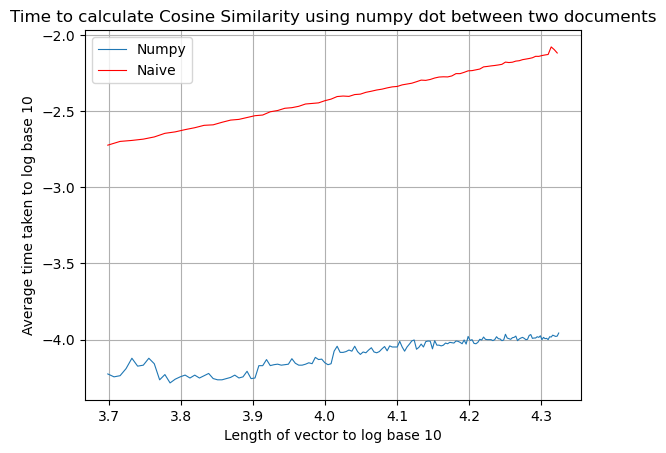

In [37]:
plt.plot(log_xcos_numpy, log_ycos_numpy, linestyle='-', linewidth=0.8, label='Numpy')

# Plot the second dataset as a thin line

plt.plot(log_x_adjust, log_y_adjust, linestyle='-', linewidth=0.8, label='Naive', color='red')

# Add labels and title
plt.xlabel("Length of vector to log base 10")
plt.ylabel("Average time taken to log base 10")
plt.title("Time (s) to calculate Cosine Similarity using numpy dot between two documents")
plt.legend()  # Add legend to distinguish datasets
plt.grid(True)  # Optional: Add grid for better readability

# Show the plot
plt.show()

Numpy's dot function significantly outperforms the naive method. While cosine similarity computation should theoretically scale linearly with WFV size, the graph shows a sub-linear slope (~0.5) at current vector lengths, likely due to numpy's optimisation for small vectors. This may stem from reduced overhead in address translations, as numpy stores data contiguously. However, the relationship should ultimately become linear with longer WFVs. To test this, I will extend the vectors by a factor of 100.

In [47]:
long_array1 =np.tile(array1,100)
long_array2 =np.tile(array2,100)
length_long_data = len(long_array1)
#print(long_array1.size) #2119800
(x_cos_numpy_long, y_cos_numpy_long) = make_data(5000, length_long_data, 10000, numpy_cosine, long_array1, long_array2, repeats=20) 

2119800


In [51]:
log_xcos_numpy_long = [np.log10(x) for x in x_cos_numpy_long]
log_ycos_numpy_long = [np.log10(y) for y in y_cos_numpy_long]

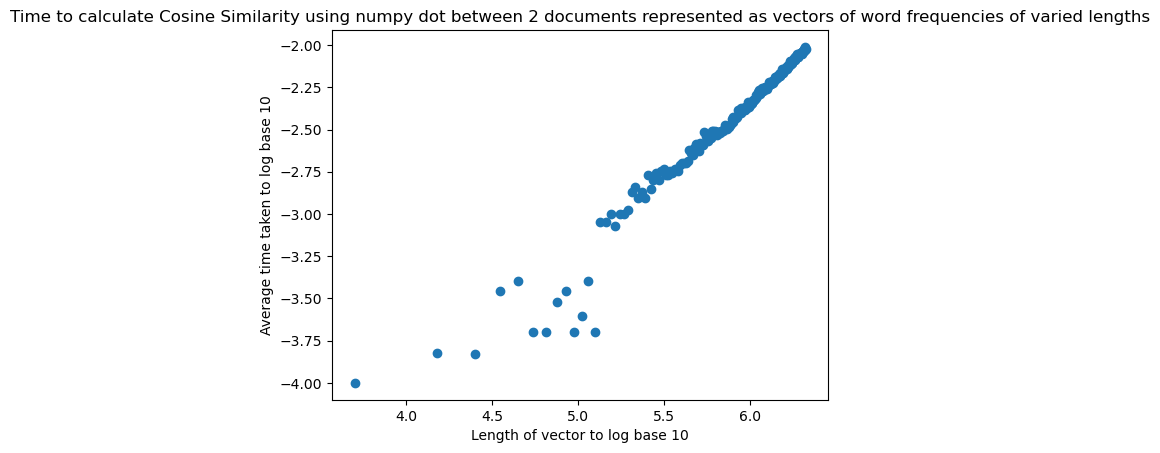

In [52]:
plt.scatter(log_xcos_numpy_long,log_ycos_numpy_long)
plt.xlabel("Length of vector to log base 10")
plt.ylabel("Average time(s) taken to log base 10")
plt.title("Time to calculate Cosine Similarity using numpy dot between 2 very large documents represented as vectors of word frequencies of varied lengths")
plt.show()

In [53]:
longnumpyres = stats.linregress(log_xcos_numpy_long, log_ycos_numpy_long)
print("Slope is {} and intercept is {}".format(longnumpyres.slope,longnumpyres.intercept))

Slope is 0.9187993859157151 and intercept is -7.849595429795476


The slope is now much closer to linear. Beyond lengths of 300,000, the data stabilises as longer computation times make CPU fluctuations- that significantly affect shorter vector lengths- comparatively small.


2) To analyse Jaccard, I will follow the same approach as with Cosine: examine the formula, gather empirical data, and use logarithmic plots to assess linearity (expected). The y-intercept will indicate the key constant.


$Jacc(A,B) = \frac{A \cap B} {A + B - A \cap B}$ extended to bags $Jacc(A,B) = \frac  {\sum_i (min(S_{i1} , S_{i2})} { \sum_i(S_{i1} + S_{i2} - min(S_{i1} , S_{i2}))}$
In Jaccard similarity applied to bags, the time complexity is dominated by the pairwise comparison that arises from the $min$ operation, each comparison is $O(1)$ but there are as many comparisons as there are items in each list, computing all of them is thus an $O(n)$ operation.
.

In [7]:
# Jaccard Similarity function
def jaccard(doca, docb):
    """Function to compute Jaccard similarity
args: vector1, vector2
return Jaccard similarity value in float form"""
    intersection =0
    union =0
    
    for i, j in zip(doca, docb):
        intersection += min(i, j)  # Add the minimum count to intersection
        union += max(i, j)         # Add the maximum count to union
    
    return intersection / union if union != 0 else 0  # To avoid division by zero
# print(jaccard(doc_1, doc_2)) =0.40404

In [64]:
# (x_jacc, y_jacc) = make_data(1000, length_of_data, 100, jaccard, array1, array2, repeats= 100)
# plt.scatter(x_jacc,y_jacc)
# plt.xlabel("Length of vector")
# plt.ylabel("Average time (s) taken")
# plt.title("Time to calculate Jaccard Similarity between doc1 and doc2 represented as vectors of word frequencies of varied lengths")
# plt.show()

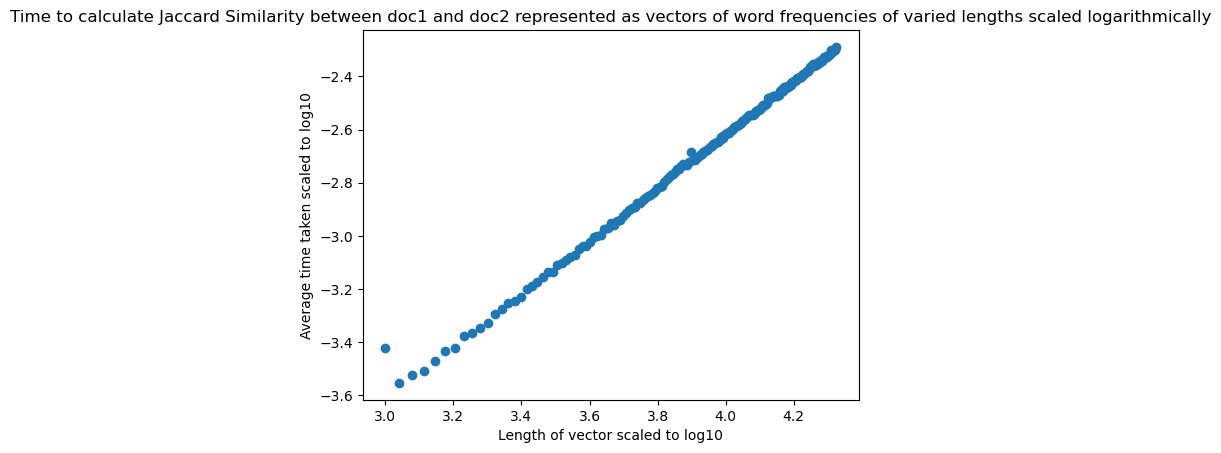

In [62]:
#np.seterr(divide = 'ignore') # for toggling on/off divide by zero warnings
np.seterr(divide = 'warn') 
logxjacc = [np.log10(x) for x in x_jacc]
logyjacc = [np.log10(y) for y in y_jacc]

plt.scatter(logxjacc,logyjacc)
plt.xlabel("Length of vector scaled to log base 10")
plt.ylabel("Average time (s) taken scaled to log base 10")
plt.title("Time to calculate Jaccard Similarity between doc1 and doc2 represented as vectors of word frequencies of varied lengths scaled logarithmically")
plt.show()

In [63]:
jaccres = stats.linregress(logxjacc, logyjacc)
print("Slope is {} and intercept is {}".format(jaccres.slope,jaccres.intercept))

Slope is 0.9896583637503558 and intercept is -6.576816840776189


As expected the slope is around 1 (0.97-1.03 from numerous repeats) The key constant for this set calculation for my computer was $2.24008342\times10^{-7}$ in this test- incredibily small and represents there being very little overhead to run this experiment.

3) The theoretical worst-case for computing all-pairs similarities is $O(n^2*d)$ where $d$ is a constant representing dimensionality of the paired items. This occurs when all documents are densely populated and completely dissimilar, so every single word count in every single document is compared with each other document. 
This simplifies to $O(n^2)$ for large datasets. Since the Jaccard/Cosine similarity of $A$ with $B$ equals that of $B$ with $A$, and the similarity of $A$ with itself is always 1, it is unnecessary to compute permutations or identical pairs. Adding a document $n$ increases calculations by $\frac {n(n-1} {2}$​, which simplifies to  $O(n^2)$ when lower-degree terms are ignored. This approach, while faster, has the same degree of time complexity as calculating permutations. For efficiency, I will focus on unique combinations, which should yield a slope near 2 on a logarithmic scale. 
As both Jaccard and Cosine are of $O(n)$ time-complexity, choosing one or the other should not be significant in terms of our worst-case time complexity for computing all-pairs of similarities. I will simulate and time both to confirm:
m:

In [10]:
# def make_pairs(list):
#     return [(list_of_docs[i], list_of_docs[j]) for i in range(len(list_of_docs)) for j in range(i + 1, len(list_of_docs))]

# list_of_pairs = make_pairs(list_of_docs)
# #print(list_of_pairs)
# print(len(list_of_pairs)) # =105 pairs with 15docs

def compute_all_pairs_jaccard(documents):
    n = len(documents)
    results = []
    for i in range(n):
        for j in range(i + 1, n):
            results.append(jaccard(documents[i], documents[j]))
    return results  # A list of Jaccard similarity values
    
#print(compute_all_pairs_jaccard(list_of_docs[:15]))
#print(len(compute_all_pairs_jaccard(list_of_docs[:15]))) #is 105 as we expect


In [9]:
xallpairs =[]
for x in range(2, 16): #ignore calc with 0 documents and 1 document
    if len(xallpairs) >= 14:
        xallpairs.clear() #to avoid appending every time this cell is called
        xallpairs.append(x)
    else:
        xallpairs.append(x)
    
yallpairs = []
for y in range(2, 16):
    if len(yallpairs) >=14:
        yallpairs.clear()
        yallpairs.append(timeit(compute_all_pairs_jaccard, array_of_docs[:y], repeats = 20))
    else:
        yallpairs.append(timeit(compute_all_pairs_jaccard, array_of_docs[:y], repeats = 20))

#Could be worth testing with fewer pairs to see if the easier load is handled faster and closer to the theoretical limit.

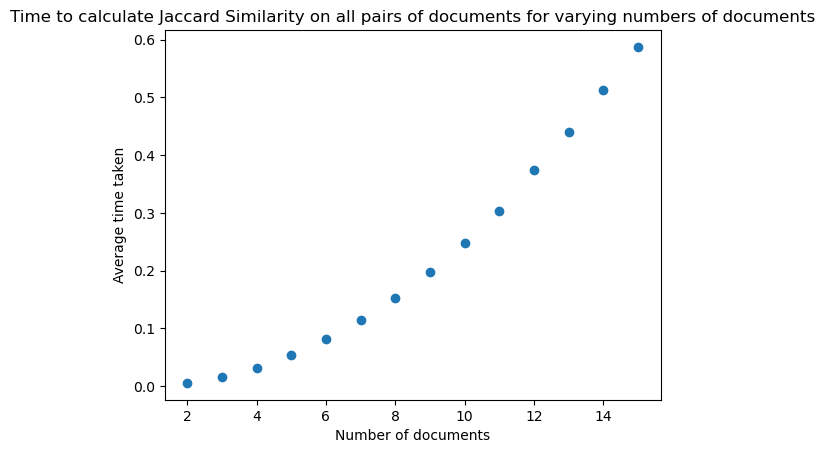

In [93]:
plt.scatter(xallpairs, yallpairs)
plt.xlabel("Number of documents")
plt.ylabel("Average time (s) taken")
plt.title("Time to calculate Jaccard Similarity on all pairs of documents for varying numbers of documents")
plt.show()

In [94]:
logxallpairs = [np.log10(x) for x in xallpairs]
logyallpairs = [np.log10(y) for y in yallpairs]

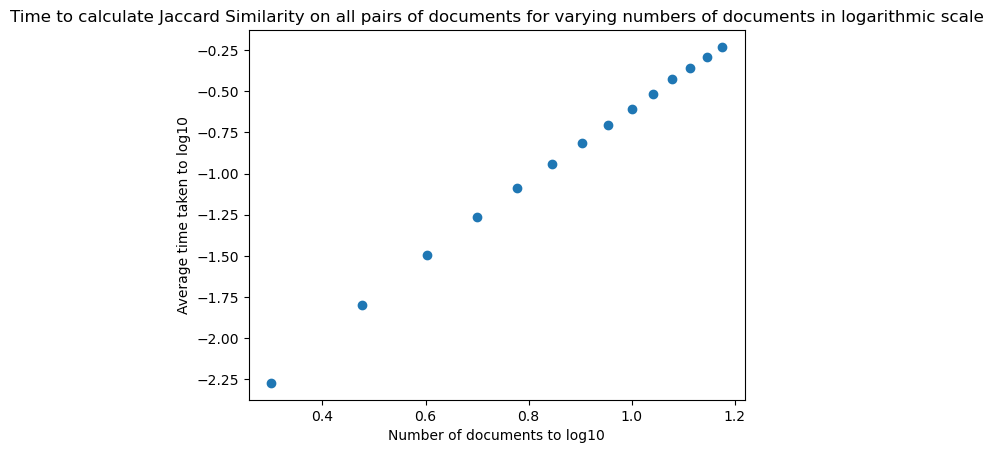

In [95]:
plt.scatter(logxallpairs,logyallpairs)
plt.xlabel("Number of documents to log base 10")
plt.ylabel("Average time (s) taken to log base 10")
plt.title("Time to calculate Jaccard Similarity on all pairs of documents for varying numbers of documents in logarithmic scale")
plt.show()

In [96]:
apjaccres = stats.linregress(logxallpairs, logyallpairs)
print("Slope is {} and intercept is {}".format(apjaccres.slope,apjaccres.intercept))

Slope is 2.293965991491075 and intercept is -2.9002642493310886


After various retests the slope varies between 2.20 and 2.33 this is a percentage difference of 5.7%.This is in-line with the hypothesised theoretical limit. The key intercept varies between 0.0023 and 0.0025. 

In [11]:
def compute_all_pairs_cosine(documents):
    n = len(documents)
    results = []
    for i in range(n):
        for j in range(i + 1, n):
            results.append(cosine_n(documents[i], documents[j]))
    return results  # A list of cosine similarity values

In [106]:
x_ap_cos =[]
for x in range(2, 16): #ignore calc with 0 documents and 1 document
    if len(x_ap_cos) >= 14:
        x_ap_cos.clear()
        x_ap_cos.append(x)
    else:
        x_ap_cos.append(x)
    
    
y_ap_cos = []
         
for y in range(2, 16):
    if len(y_ap_cos) >= 14:
        y_ap_cos.clear()
        y_ap_cos.append(timeit(compute_all_pairs_cosine, array_of_docs[:y], repeats = 20))
    else:
        y_ap_cos.append(timeit(compute_all_pairs_cosine, array_of_docs[:y], repeats = 20))

In [107]:
logxap_cos = [np.log10(x) for x in x_ap_cos]
logyap_cos = [np.log10(y) for y in y_ap_cos]

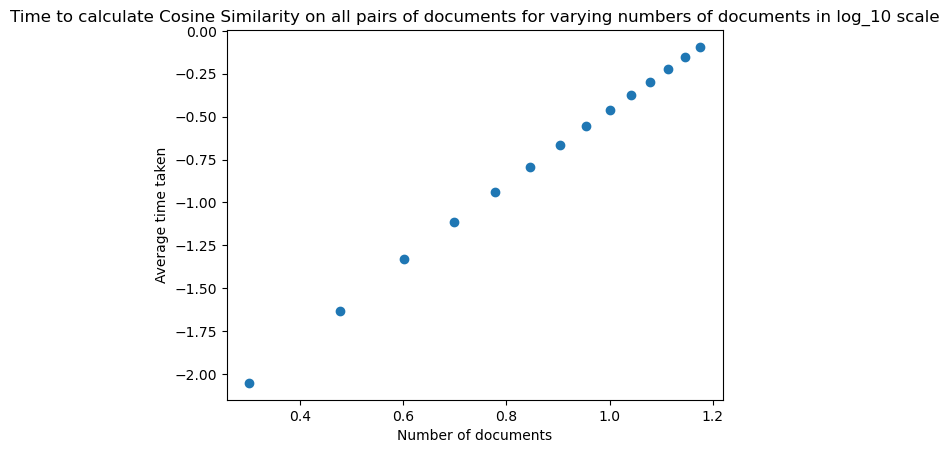

In [108]:
plt.scatter(logxap_cos,logyap_cos)
plt.xlabel("Number of documents to log base 10")
plt.ylabel("Average time (s) taken to log base 10")
plt.title("Time to calculate Cosine Similarity on all pairs of documents for varying numbers of documents")
plt.show()

In [194]:
# plt.scatter(x_ap_cos,logyap_cos)
# plt.xlabel("Number of documents")
# plt.ylabel("Average time taken")
# plt.title("Time to calculate Cosine Similarity on all pairs of documents for varying numbers of documents in logarithmic scale")
# plt.show()

# print(len(x_ap_cos))
# print(x_ap_cos)
# print(len(logyap_cos))

In [109]:
apcosres = stats.linregress(logxap_cos, logyap_cos)
print("Slope is {} and intercept is {}".format(apcosres.slope,apcosres.intercept))

Slope is 2.220192675662969 and intercept is -2.6845159049537375


As expected the slope and y intercept remain very similar for computing the naive cosine similarity or jaccard on all-pair and I've noted a similar degree of variance, 2.22-2.30 over various simulations, a 4.44% difference.


And with Numpy:

In [12]:
def compute_all_pairs_cosine_numpy(documents):
    n = len(documents)
    results = []
    for i in range(n):
        for j in range(i + 1, n):
            results.append(numpy_cosine(documents[i], documents[j]))
    return results  # A list of cosine similarity values

In [87]:
x_ap_cos_numpy =[]
for x in range(2, 16): #ignore calc with 0 documents and 1 document
    if len(x_ap_cos_numpy) >= 14:
        x_ap_cos_numpy.clear()
        x_ap_cos_numpy.append(x)
    else:
        x_ap_cos_numpy.append(x)
    
y_ap_cos_numpy = []
for y in range(2, 16):
    if len(y_ap_cos_numpy) >= 14:
        y_ap_cos_numpy.clear()
        y_ap_cos_numpy.append(timeit(compute_all_pairs_cosine_numpy, array_of_docs[2:y], repeats = 500))
    else: 
        y_ap_cos_numpy.append(timeit(compute_all_pairs_cosine_numpy, array_of_docs[2:y], repeats = 500))


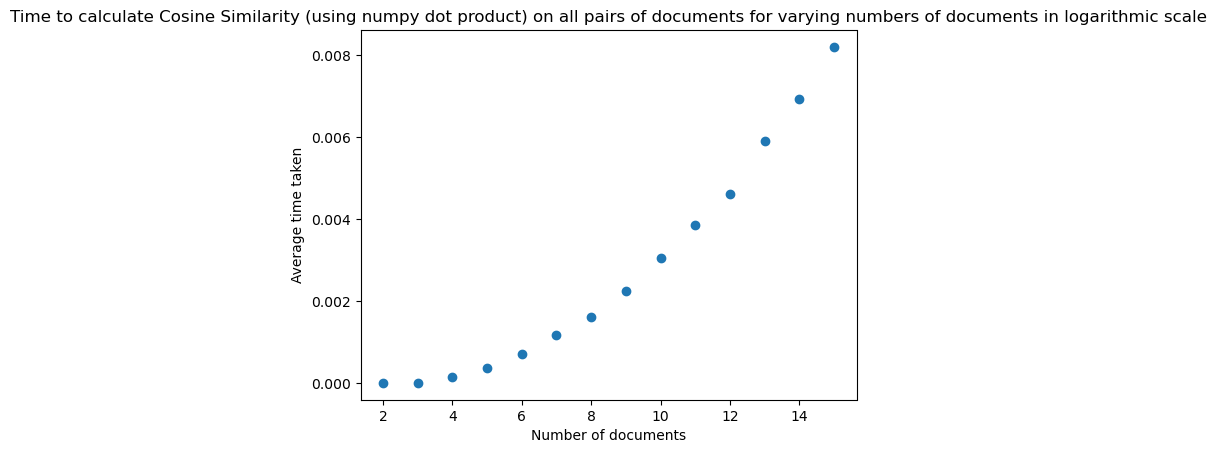

In [88]:
plt.scatter(x_ap_cos_numpy,y_ap_cos_numpy)
plt.xlabel("Number of documents")
plt.ylabel("Average time (s) taken")
plt.title("Time to calculate Cosine Similarity (using numpy dot product) on all pairs of documents for varying numbers of documents")
plt.show()

In [102]:
x_ap_cos_numpy_adjust = x_ap_cos_numpy[3:]
y_ap_cos_numpy_adjust = y_ap_cos_numpy[3:]
x_ap_cos_numpy_log = [np.log10(x) for x in x_ap_cos_numpy_adjust]
y_ap_cos_numpy_log = [np.log10(y) for y in y_ap_cos_numpy_adjust]

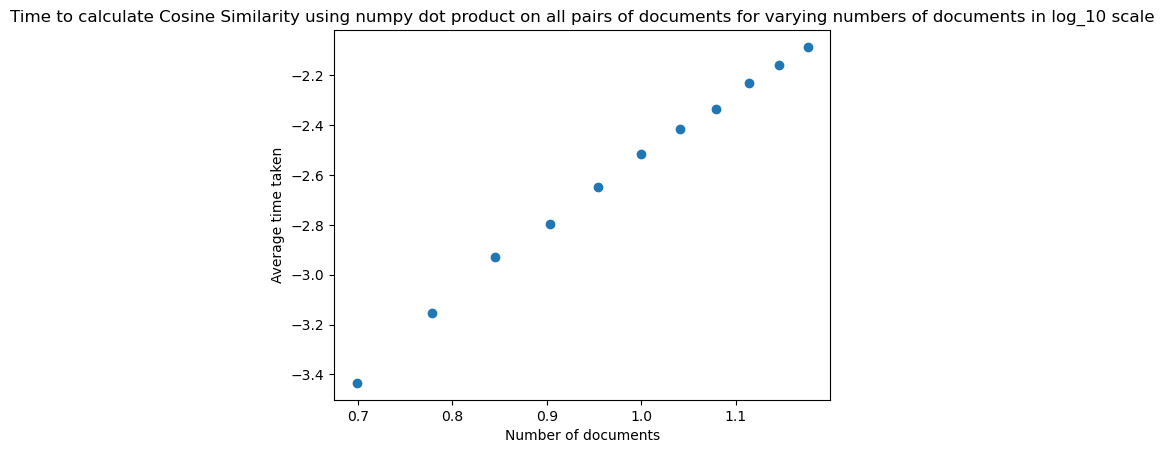

In [103]:
plt.scatter(x_ap_cos_numpy_log,y_ap_cos_numpy_log)
plt.xlabel("Number of documents to log base 10")
plt.ylabel("Average time (s) taken to log base 10")
plt.title("Time to calculate Cosine Similarity using numpy dot product on all pairs of documents for varying numbers of documents")
plt.show()

In [105]:
apcosnumpyres = stats.linregress(x_ap_cos_numpy_log, y_ap_cos_numpy_log)
print("Slope is {} and intercept is {}".format(apcosnumpyres.slope,apcosnumpyres.intercept))

Slope is 2.7621544907988698 and intercept is -5.305189785278613


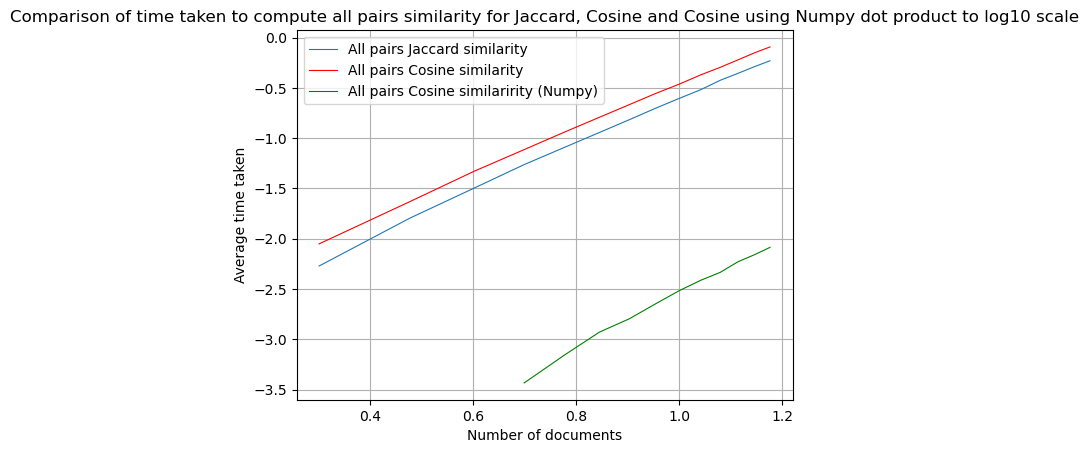

In [110]:
plt.plot(logxallpairs,logyallpairs, linestyle='-', linewidth=0.8, label='All pairs Jaccard similarity')
plt.plot(logxap_cos,logyap_cos, linestyle='-', linewidth=0.8, label='All pairs Cosine similarity', color='red')
plt.plot(x_ap_cos_numpy_log,y_ap_cos_numpy_log, linestyle='-', linewidth=0.8, label='All pairs Cosine similaririty (Numpy)', color='green')
plt.xlabel("Number of documents to log base 10")
plt.ylabel("Average time (s) taken to log base 10")
plt.title("Comparison of time (s) taken to compute all pairs similarity for Jaccard, Cosine and Cosine using Numpy dot product")
plt.legend() 
plt.grid(True)  
plt.show()

Naive Jaccard and naive Cosine Similarity produced a slope of negligable difference (1.6%) as this is within the variance observed for computing either (5.70% and 4.44% respectively). Numpy seems to take advantage of the previously mentioned speed-ups and outperforms both.

4) To do this, I will set up a "worker" function. Using an auxiliary file, myworker.py (shown below), I will measure the average time to compute cosine similarity for all document pairs with varying numbers of processes and up to 15 documents (105 unique pairings). Given the sparse matrix, which isn't taxing for a single core, I expect that overhead from parallelism will cause a slowdown at relatively low process counts. This slowdown will become more noticeable beyond the number of logical processors available (24).
For parallel computing to provide a speed up here I would expect that the task would need to be sufficiently labour intensive to justify the overhead incurred by having to coordinate multiple processors.

In [ ]:
# import math
# from itertools import combinations
# from multiprocessing import Pool


# def dotn(v1,v2):
#     total=0
#     for i in range(0,len(v1)):
#         total+=v1[i]*v2[i]
        
#     return total

# def cosine_n(v1,v2): #cosine naive
    
#     return dotn(v1,v2)/math.sqrt(dotn(v1,v1)*dotn(v2,v2))

# def compute_pairwise_chunk(chunk):
#     """Compute cosine similarities for a given chunk of document pairs."""
#     return [cosine_n(pair[0], pair[1]) for pair in chunk] 

# def worker(documents, num_processes):
#     """Compute all pairwise cosine similarities using chunking and parallel processing.
# args: document matrix, how many processes to run- int"""
#     pairs = list(combinations(documents, 2)) #gives the unique combinations of document pairs
#     chunk_size = len(pairs) // num_processes 
#     chunks = [pairs[i * chunk_size: (i + 1) * chunk_size] for i in range(num_processes)] #slices our pairs list appropriately for num_processes
    
#     if len(pairs) % num_processes: #handles remainder
#         chunks[-1].extend(pairs[num_processes * chunk_size:])
    
#     with Pool(processes=num_processes) as pool:
#         results = pool.map(compute_pairwise_chunk, chunks)
    
#     final_res = [sim for result in results for sim in result] #collates all of our individual process results into one list
#     return final_res

In [13]:
def run_worker_with_repeats(documents, num_processes, repeats):
    """Run the worker function with the given number of processes and repeats."""
    total_time = 0  # To accumulate total time
    
    for _ in range(repeats):
        start_time = time.time()
        myworker.worker(documents, num_processes)  # Run the worker function
        end_time = time.time()
        total_time += (end_time - start_time)  # Add the time taken for this repeat
    
    mean_time = total_time / repeats  # Calculate mean time
    return mean_time

In [111]:
#times_multi_1.clear() #In case of re-runs to avoid re-appending

In [150]:
times_multi_1 = []
for i in range(1, 30):
    times_multi_1.append(run_worker_with_repeats(list_of_docs, i, 10))

In [117]:
# print(len(times_multi))
# x_axis_multi = list(range(1,30))

29


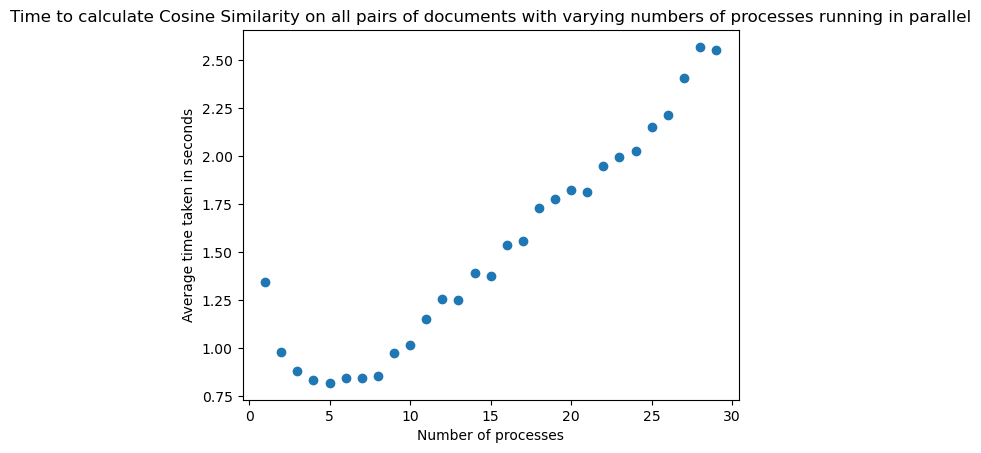

In [151]:
plt.scatter(x_axis_multi,times_multi_1)
plt.xlabel("Number of processes")
plt.ylabel("Average time taken in seconds")
plt.title("Time to calculate Cosine Similarity on all pairs of documents with varying numbers of processes running in parallel")
plt.show()


In [9]:
print(times_multi_1) # run times_multi

NameError: name 'times_multi_1' is not defined

Five processes appear to be optimal for computing cosine similarity across all document pairs. Beyond this, the overhead time from parallelism outweighs the benefits. Additionally, for factors of 105 (e.g., 5, 7, 15, 21 processes), the data points slightly fall below the expected line of best fit. This is likely due to each process handling an equal number of pairs, causing them to finish at similar times. As computation speed is limited by the slowest process, this affects the results. Also, the if condition in the worker function doesn't need to compute beyond if len(pairs) % num_processes:, as there’s no remainder.

To further investigate I have plotted how the time taken varies with the amount of documents:


In [140]:
times_multi = []

# Loop over the number of documents
for n in range(2, 16):
    times_for_docs = []  # Reset times_for_docs for each value of n
    # Loop over the number of processes
    for i in range(1, 30):
        time_taken = run_worker_with_repeats(list_of_docs[:n], i, 1)
        times_for_docs.append(time_taken)
    
    times_multi.append(times_for_docs)


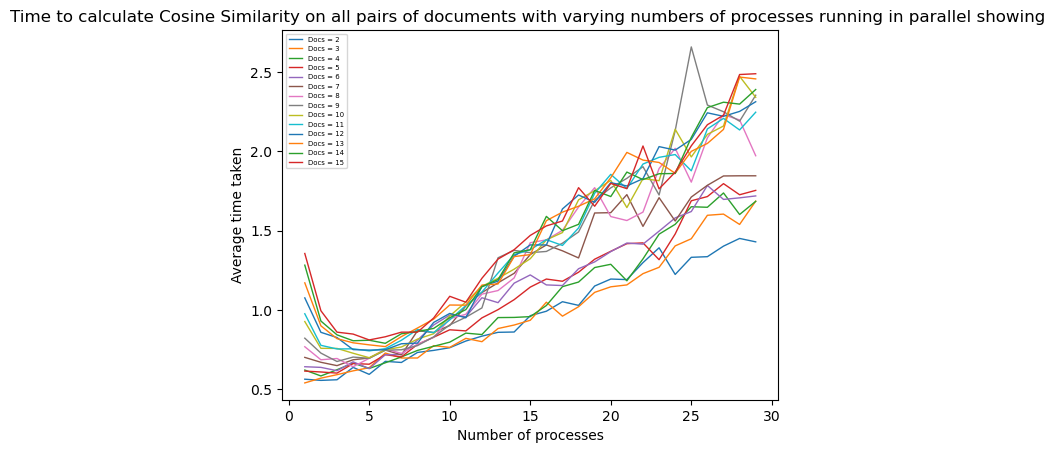

In [144]:
for i, times_for_docs in enumerate(times_multi, start=1):
   
    plt.plot(x_axis_multi, times_for_docs, label=f"Docs = {i+1}", linewidth=1)  

plt.xlabel("Number of processes")
plt.ylabel("Average time (s) taken")
plt.title("Time (s) to calculate Cosine Similarity on all pairs of documents with varying numbers of documents and varying numbers of processes running in parallel showing ")

plt.legend(loc='best', fontsize=5)

plt.show()

The general trend suggests that the more documents being processed, the greater the potential for speed-up from parallel computing, though there is an optimal point beyond which additional processes lead to slowdowns. For runs with fewer documents, speed-up is minimal and typically achieved with 2-3 processes for 2-5 documents. With larger datasets, the optimal number of processes seems to be 5. For a dataset with more documents, a higher number of processes could yield further speed-up, as the overhead time would be outweighed by the benefit of parallelising more document pairings. Additionally, slight speed-ups may occur when the number of processes is a factor of the total unique pairs, though this is hard to confirm due to noisy data from not running repeats. I opted not to run repeats to save time, as computing all pairwise cosines for 15 documents using 1 to 30 processes involves approximately 50,000 cosine similarity calculations.


5) In order to demonstrate how Strassen's method can compute cosine similarity more efficiently for all pairs of documents than the naive method of matrix multiplication I will first analyse the process of how to get from matrix multiplication to values of cosine similarity in order to comment on where time can be saved and what factors influence the time complexity of the computation. I will then demonstrate this empirically by timing and comparing the rate determining factors in each approach.

To get from the result matrix to our cosine similarity value is a relatively straight forward operation that I will illustrate with a simplified example: $$A.T= 
\begin{bmatrix}
V_{11} & V_{12} & V_{13} \\
V_{21} & V_{22} & V_{23} \\
V_{31} & V_{32} & V_{33}
\end{bmatrix}
$$
This represents 3 Vectors, $V1, V2, V3$ of dimensionality 3- a stand-in for our 15 documents with dimensionality of $20000+$. And so:

$$A.TA= 
\begin{bmatrix}
V_{11} & V_{12} & V_{13} \\
V_{21} & V_{22} & V_{23} \\
V_{31} & V_{32} & V_{33}
\end{bmatrix}
\begin{bmatrix}
V_{11} & V_{21} & V_{31} \\
V_{12} & V_{22} & V_{32} \\
V_{13} & V_{23} & V_{33}
\end{bmatrix} =\begin{bmatrix}
V1.V1 & V1.V2 & V1.V3 \\
V2.V1 & V2.V2 & V2.V3 \\
V3.V1 & V3.V2 & V3.V3
\end{bmatrix}
$$
Referring to the equation for cosine similarity::

$$Cosine Similarity = cos(\theta) = \frac{A \cdot B} {\sqrt {A \cdot A \times B \cdot B}}$$
A straightforward operation can be taken to yield the cosine similarity for each document pairing- as the upper right triangle of the resultant matrix represents each unique pairing of documents. Dividing each of these upper right triangle values by the multiplication of the square root of the 2 values in the diagonal with which they share a row and column yields the cosine similarity for each document pairing. Appending the diagonal values to a list as the result matrix is calculated, performing this final step becomes $O(1)$ as all that is required is referencing into the list. If there is a higher order time complexity step within the matrix multiplication step the final computation of cosine similarity can be ignored as it will be irrelevant to the time complexity overall. The formula of naive matrix multiplication can be represented as such:
:
$$C[i, j] = \sum_{k=1}^{n} A[i, k] \cdot B[k, j]$$
Showing a dot product, which as stated previously is an $O(n)$ operation that has to be computed for every $n$ row in $A$ and $n$ column in $B$, resulting in an overall time complexity of $n*n*O(n) = O(n^3)$ Strassen's method, with reference to 2 2x2 matrices, instead utilises recursive multiplications on intermediate values (shown below) to bring the total number of multiplications down from the 8 in traditional matrix multiplication to 7 but requires 18 additions compared to the naive's 4. Using Master Theorem as shown in Introduction to Algorithms by Cormen et al it can be shown that the overall time complexity of this method is $O(n^{2.81})$. So in theory, for sufficiently large matrices Strassen will be more efficient, but at smaller sizes- due to the extra additions required- the naive method should outperform. 
I will demonstrate this empirically via timing how long they both take to compute the multiplication of 2 square matrices and comparing. To make the data applicable to finding cosine similarity the square matrices I will have them compute will be square cuts (using the function square_cut) from the data matrix padded with zeros where necessary.
_cut.

In [122]:
#Example of code to find cosine simiularity from matrix multiplication -unused
#def naivemult_cos(A, B):
 
#     (m, n) = np.shape(A)
    
#     # Initialise the result matrix
#     C = np.zeros([m, m])
    
#     # List to store diagonal values
#     diagonal_values = []
    
#     # List to store above-diagonal elements with their indices
#     normalized_above_diagonal = []
    
#     # Perform naive matrix multiplication
#     for i in range(m):
#         for j in range(m):
#             for k in range(m):
#                 C[i, j] += A[i, k] * B[k, j]
        
#         # Append diagonal element as it is computed
#         diagonal_values.append(C[i, i])
    
#     # Normalize above-diagonal elements
#     for i in range(m):
#         for j in range(i + 1, m):  # Only consider elements above the diagonal
#             if C[i, i] > 0 and C[j, j] > 0:  # Avoid division by zero
#                 normalization_factor = np.sqrt(C[i, i] * C[j, j])
#                 normalized_value = C[i, j] / normalization_factor
#                 normalized_above_diagonal.append(((i, j), normalized_value))
#             else:
#                 normalized_above_diagonal.append(((i, j), 0))  # Assign 0 if diagonal elements are non-positive
    
#     return C, diagonal_values, normalized_above_diagonal

In [116]:
def square_cut(matrix, size):
    """
    Extracts a square cut from the top-left corner of a matrix, padding with zeros if necessary.
    
    args:
        matrix (numpy.ndarray): The input matrix.
        size (int): The desired size of the square cut.
    
    return:
        numpy.ndarray: A square matrix of the specified size, padded with zeros if out of bounds.
    """
    # Get the shape of the input matrix
    rows, cols = matrix.shape
    
    # Create a zero matrix of the desired size
    result = np.zeros((size, size))
    
    # Determine the overlapping region between the matrix and the result
    overlap_rows = min(rows, size)
    overlap_cols = min(cols, size)
    
    # Copy the overlapping region from the input matrix to the result
    result[:overlap_rows, :overlap_cols] = matrix[:overlap_rows, :overlap_cols]
    
    return result


In [117]:
def naivemult(A,B):

    (m,n) = np.shape(A)
        
    C = np.zeros([m,m])
    
    for i in range(m):
        for j in range(m):
            for k in range(m):
                C[i,j] += A[i,k] * B[k,j]
        
    return C

In [118]:
def split(matrix):
	"""
	Splits a given matrix into quarters.
	args: nxn matrix
	return: tuple containing 4 n/2 x n/2 matrices corresponding to a, b, c, d
	"""
	row, col = matrix.shape
	row2, col2 = row//2, col//2
	return matrix[:row2, :col2], matrix[:row2, col2:], matrix[row2:, :col2], matrix[row2:, col2:]

def strassen(x, y):
	"""
	Computes matrix product by divide and conquer approach, recursively.
	param: nxn matrices x and y
	return: nxn matrix, product of x and y
	"""

	# Base case when size of matrices is 1x1
	if len(x) == 1:
		return x * y

	# Splitting the matrices into quadrants. This will be done recursively
	# until the base case is reached.
	a, b, c, d = split(x)
	e, f, g, h = split(y)

	# Computing the 7 products, recursively (p1, p2...p7)
	p1 = strassen(a, f - h) 
	p2 = strassen(a + b, h)	 
	p3 = strassen(c + d, e)	 
	p4 = strassen(d, g - e)	 
	p5 = strassen(a + d, e + h)	 
	p6 = strassen(b - d, g + h) 
	p7 = strassen(a - c, e + f) 

	# Computing the values of the 4 quadrants of the final matrix c
	c11 = p5 + p4 - p2 + p6 
	c12 = p1 + p2		 
	c21 = p3 + p4		 
	c22 = p1 + p5 - p3 - p7 

	# Combining the 4 quadrants into a single matrix by stacking horizontally and vertically.
	c = np.vstack((np.hstack((c11, c12)), np.hstack((c21, c22)))) 

	return c


In [119]:
x_matrix_lengths = list(range(100, 600, 50))
x_matrixes = []
y_timed_naive = []
for n in range(100, 600, 50):
    x_matrixes.append(square_cut(documents1, n))

for i, matrix in enumerate(x_matrixes):
    # Pass the matrix directly without using x as an index
    y_timed_naive.append(timeit(naivemult, matrix.T, matrix, repeats=1))



In [136]:
# plt.scatter(x_matrix_lengths, y_timed_naive)
# plt.xlabel("Matrix length")
# plt.ylabel("Average time taken in seconds")
# plt.title("Time to calculate Cosine Similarity on all pairs of documents via naive matrix multiplication")
# plt.show()


In [120]:
logxnaive = [np.log10(x) for x in x_matrix_lengths]
logynaive = [np.log10(y) for y in y_timed_naive]

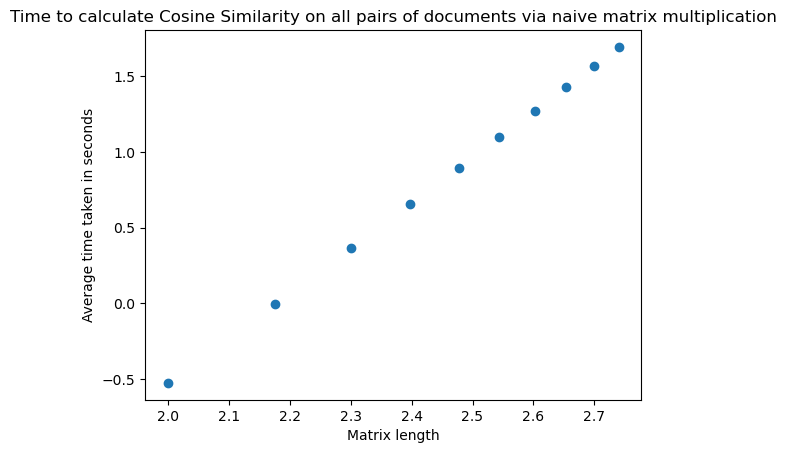

In [121]:
plt.scatter(logxnaive, logynaive)
plt.xlabel("Matrix length to log base 10")
plt.ylabel("Average time taken in seconds to log base 10")
plt.title("Time to calculate Cosine Similarity on all pairs of documents via naive matrix multiplication")
plt.show()

In [122]:
naivematres = stats.linregress(logxnaive, logynaive)
print("Slope is {} and intercept is {}".format(naivematres.slope,naivematres.intercept))

Slope is 3.0003192727524426 and intercept is -6.535017696076171


In [137]:
# plt.scatter(strassen_matrix_lengths, y_times_strassen)
# plt.xlabel("Matrix length")
# plt.ylabel("Average time taken in seconds")
# plt.title("Time to calculate Cosine Similarity on all pairs of documents via strassen's method matrix multiplication")
# plt.show()

In [123]:
strassen_matrix_lengths = [2**i for i in range(10)] #Strassen's method only works on matricies that are a power of 2
square_matricies = []
print(strassen_matrix_lengths)
for i in strassen_matrix_lengths:
    square_matricies.append(square_cut(documents1,i))

[1, 2, 4, 8, 16, 32, 64, 128, 256, 512]


In [124]:
y_times_strassen = []

for i in square_matricies:
    y_times_strassen.append(timeit(strassen,i.T,i, repeats=1))



In [128]:
strassen_no_one = strassen_matrix_lengths[4:]
y_strassen_no_one = y_times_strassen[4:]
logxstrass = [np.log10(x) for x in strassen_no_one]
logystrass = [np.log10(y) for y in y_strassen_no_one]

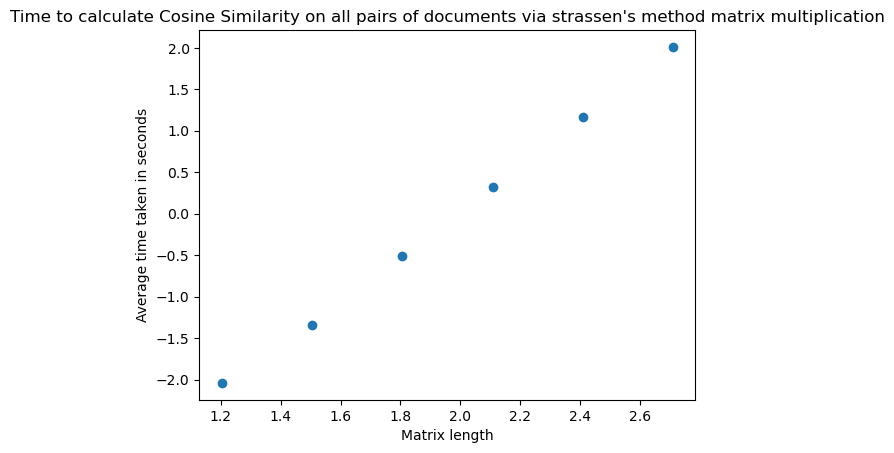

In [133]:
plt.scatter(logxstrass, logystrass)

plt.xlabel("Matrix length to log base 10")
plt.ylabel("Average time taken in seconds to log base 10")
plt.title("Time to calculate Cosine Similarity on all pairs of documents via strassen's method matrix multiplication")
plt.show()

In [109]:
strassres = stats.linregress(logxstrass,  logystrass)
print("Slope is {} and intercept is {}".format(strassres.slope,strassres.intercept))

Slope is 2.6763001127589314 and intercept is -5.274708718387276


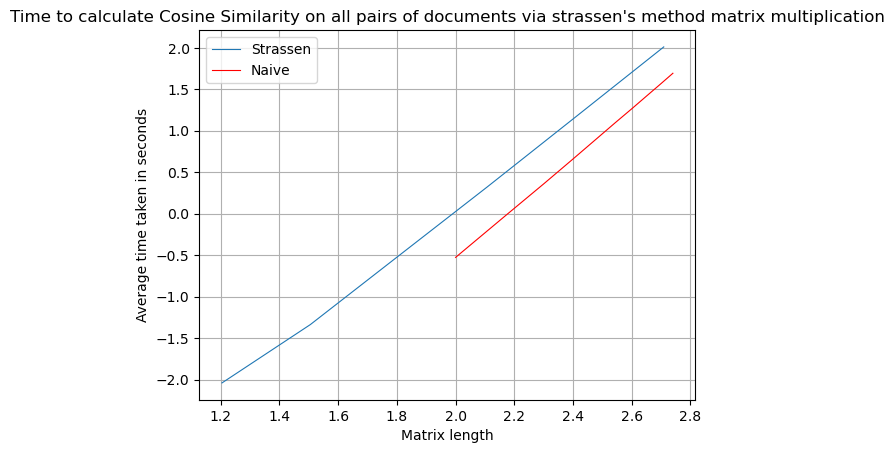

In [138]:
plt.plot(logxstrass, logystrass, linestyle ='-', linewidth=0.8, label='Strassen')
plt.plot(logxnaive, logynaive, linestyle ='-', linewidth=0.8, label='Naive', color='red')

plt.xlabel("Matrix length to log base 10")
plt.ylabel("Average time taken in seconds to log base 10")
plt.title("Time to calculate Cosine Similarity on all pairs of documents via strassen's method matrix multiplication")
plt.legend() 
plt.grid(True)  
plt.show()

The key constant for the naive matrix multiplication is significantly lower than that of Strassen's method and so for smaller matrices the naive method will outperform Strassen's method but given the Naive's steeper slope, with a sufficiently large matrix these lines will eventually cross, signifying the point at which strassen's method will be more efficient. 

In order to generate this data I had to sacrifice a degree of accuracy in the cosine similarity calculation as beyond 512 rows of the data matrix became unfeasible. In order to utilise matrix multiplication and maintain the integrity of the data in the sample, compression would be required. Below I have experimented with minhashing as an example. 


In [44]:
def minhash(matrix, num_hashes):
    """
    Generate MinHash signatures for a binary characteristic matrix using NumPy.
    
    args:
        matrix (numpy.ndarray)
        num_hashes -int: Number of hash functions to use.
        
    returns:
        numpy.ndarray: MinHash signature matrix (rows: hashes, columns: sets).
    """
    num_elements, num_sets = matrix.shape
    signatures = np.full((num_hashes, num_sets), np.inf)  # Initialize signature matrix with infinity

    # Generate random hash functions
    np.random.seed(42)  # For reproducibility
    hash_functions = [
        (np.random.randint(1, 100), np.random.randint(1, 100))  # Random (a, b) coefficients
        for _ in range(num_hashes)
    ]
    
    for i, (a, b) in enumerate(hash_functions):
        # Create hash values for all rows
        hash_values = (a * np.arange(num_elements) + b) % num_elements
        
        # Update signature matrix
        for col in range(num_sets):  # Iterate through columns (sets)
            # Consider only rows where the set contains the element (value is 1)
            relevant_hashes = hash_values[matrix[:, col] == 1]
            if len(relevant_hashes) > 0:
                signatures[i, col] = np.min(relevant_hashes)  # Update with the minimum hash value
    
    return signatures


In [120]:
num_hashes = 1024
minhash_signatures = minhash(my_data_array, num_hashes)

print("\nMinHash Signatures:")
print(minhash_signatures)



MinHash Signatures:
[[ 1. 27. 35. ...  1. 23.  1.]
 [ 3. 96.  0. ...  6. 15.  3.]
 [ 0. 56.  5. ...  5.  9.  3.]
 ...
 [ 5. 51.  2. ...  3.  8.  0.]
 [ 9. 51.  5. ...  7.  5.  9.]
 [12. 40. 38. ...  6.  0.  6.]]


In [117]:
def minhash_to_binary(minhash_table):
    """
    Convert a MinHash table to binary signatures.

    Parameters:
        minhash_table (numpy.ndarray): MinHash signature table (k x n).

    Returns:
        numpy.ndarray: Binary signatures (k x n).
    """
    # Get the number of rows (hash functions) and columns (documents)
    num_hashes, num_docs = minhash_table.shape
    
    # Initialize binary signatures with zeros
    binary_signatures = np.zeros_like(minhash_table, dtype=int)
    
    # Iterate over each row to assign binary values
    for row in range(num_hashes):
        # Find the minimum value in the row (assuming it represents the signature's target value)
        min_value = np.min(minhash_table[row, :])
        
        # Assign 1 to positions that match the minimum value
        binary_signatures[row, :] = (minhash_table[row, :] == min_value).astype(int)

    return binary_signatures
        

In [ ]:
#Word count: 1989